# MAXWELL TURNER - ASSIGNMENT 3.2 - Housing EDA - WEEK 3

## Load and Inspect the Data

In [241]:
import pandas as pd
import matplotlib.pyplot as plt

In [242]:
df = pd.read_csv("../data/california-housing.csv")
print("shape:", df.shape)
df.sample(10)

shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4299,-118.29,34.09,35.0,2198.0,998.0,3441.0,912.0,2.0467,158300.0,<1H OCEAN
14519,-117.13,32.91,16.0,2715.0,581.0,1619.0,584.0,4.0000,154700.0,<1H OCEAN
359,-122.14,37.76,34.0,1513.0,231.0,545.0,211.0,5.5701,252800.0,NEAR BAY
20472,-118.76,34.26,26.0,1750.0,284.0,962.0,278.0,4.5673,190400.0,<1H OCEAN
13400,-117.43,34.12,7.0,5954.0,1071.0,3567.0,1070.0,3.2056,134100.0,INLAND
17091,-122.23,37.48,33.0,3108.0,805.0,1895.0,717.0,3.3015,267700.0,NEAR OCEAN
19342,-122.86,38.61,52.0,1753.0,380.0,982.0,380.0,3.4013,183300.0,<1H OCEAN
16854,-122.42,37.62,36.0,1017.0,165.0,407.0,159.0,4.8000,306800.0,NEAR OCEAN
5136,-118.26,33.97,46.0,1086.0,249.0,880.0,250.0,1.5962,95700.0,<1H OCEAN
14631,-117.21,32.81,26.0,2496.0,407.0,1062.0,380.0,5.5413,302100.0,NEAR OCEAN


In [243]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


20640 districts and 10 columns. Everything is numeric except ocean_proximity which is text and total_bedrooms is the only column that isn't 20640 non null so that's where the missing data is.

In [244]:
#sum stats
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


## Handling Missing Values

In [245]:
#checking lost
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [246]:
#median not mean cause this column is skewed and only 1% missing so no point dropping rows
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
print("missing now:", df.isnull().sum().sum())

missing now: 0


207 nulls in total_bedrooms which is about 1% of the data. I filled them with the median instead of dropping the rows dropping would throw away the other 9 columns for those districts too. Median rather than mean because the column is right skewed so a few huge districts would drag the mean up.

## One Hot Encoding

In [247]:
print(df["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [248]:
#one hot turns the text into 5 true/false columns
df = pd.get_dummies(df, columns=["ocean_proximity"])
print("shape now:", df.shape)
print(df.columns.tolist())

shape now: (20640, 14)
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [249]:
df[[c for c in df.columns if "ocean" in c]].sum()

ocean_proximity_<1H OCEAN     9136
ocean_proximity_INLAND        6551
ocean_proximity_ISLAND           5
ocean_proximity_NEAR BAY      2290
ocean_proximity_NEAR OCEAN    2658
dtype: int64

Shape went from 10 columns to 14 dropped 1 text column, gained 5 true/false ones. The sums match the value_counts() above exactly so nothing got lost in the encoding. I used one hot instead of just numbering the categories 0-4 because that would tell the model INLAND is somehow less than NEAR BAY and that they're evenly spaced. They're just names, there's no order to them.

## Explore Data Visually

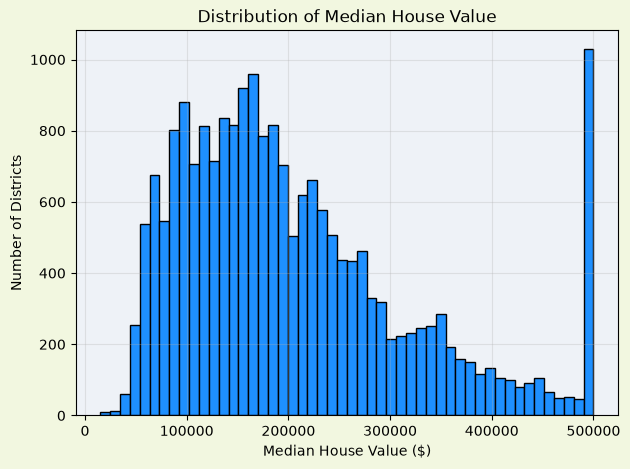

In [250]:
#house values are spread out
plt.figure(figsize=(7, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
plt.hist(df["median_house_value"], bins=50, color="dodgerblue", edgecolor="black")
plt.xlabel("Median House Value ($)")
plt.ylabel("Number of Districts")
plt.title("Distribution of Median House Value")
plt.grid(alpha=0.3)
plt.show()

Right skewed, not normal. Most districts are 100k-250k with a long tail going right. Also there's a big spike at 500001 which isn't real that's the cap, so anything above 500k got recorded as the same number.

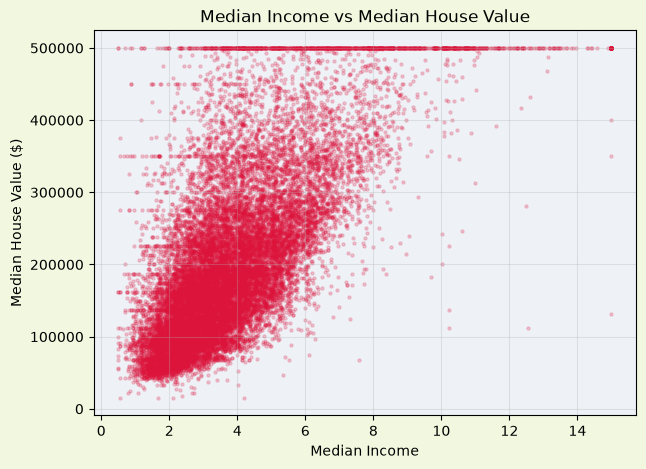

In [251]:
plt.figure(figsize=(7, 5))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
plt.scatter(df["median_income"], df["median_house_value"],
            s=5, alpha=0.2, color="crimson")
plt.xlabel("Median Income")
plt.ylabel("Median House Value ($)")
plt.title("Median Income vs Median House Value")
plt.grid(alpha=0.3)
plt.show()

Kinda linear but not really. Price does go up with income, which is the strongest relationship in the data, but it's a wide fuzzy cloud not a tight line. And there's that solid line of dots across the top at 500000 from the cap, so past a certain income the price just stops going up which no straight line can handle.

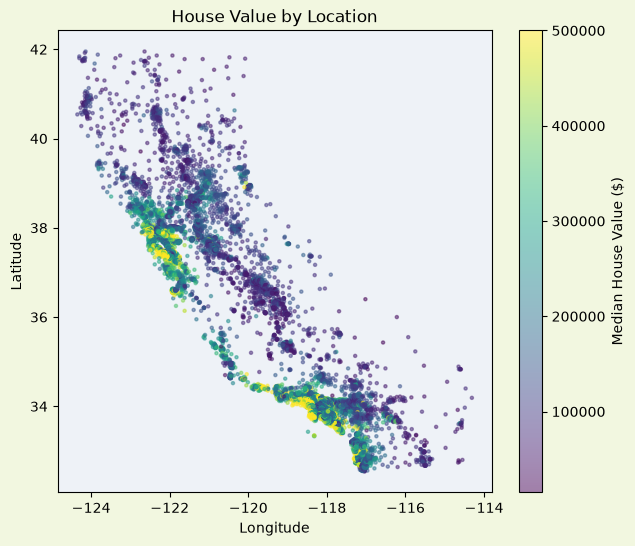

In [252]:
plt.figure(figsize=(7, 6))
plt.gcf().set_facecolor("#f2f7e0")
plt.gca().set_facecolor("#eef2f7")
sc = plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                 cmap="viridis", s=5, alpha=0.5)
plt.colorbar(sc, label="Median House Value ($)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Value by Location")
plt.show()

You can literally see California (my home state :D). The coast is all yellow/expensive and inland is dark/cheap, with the Bay Area and LA being the brightest spots. So location matters a lot, but not in a straight line way it's not "west = expensive", it's more like distance from those specific coastal cities.

## Correlation

In [253]:
num_cols = df.select_dtypes("number")
corr = num_cols.corr()
print(corr["median_house_value"].sort_values(ascending=False).round(3))

median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.049
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


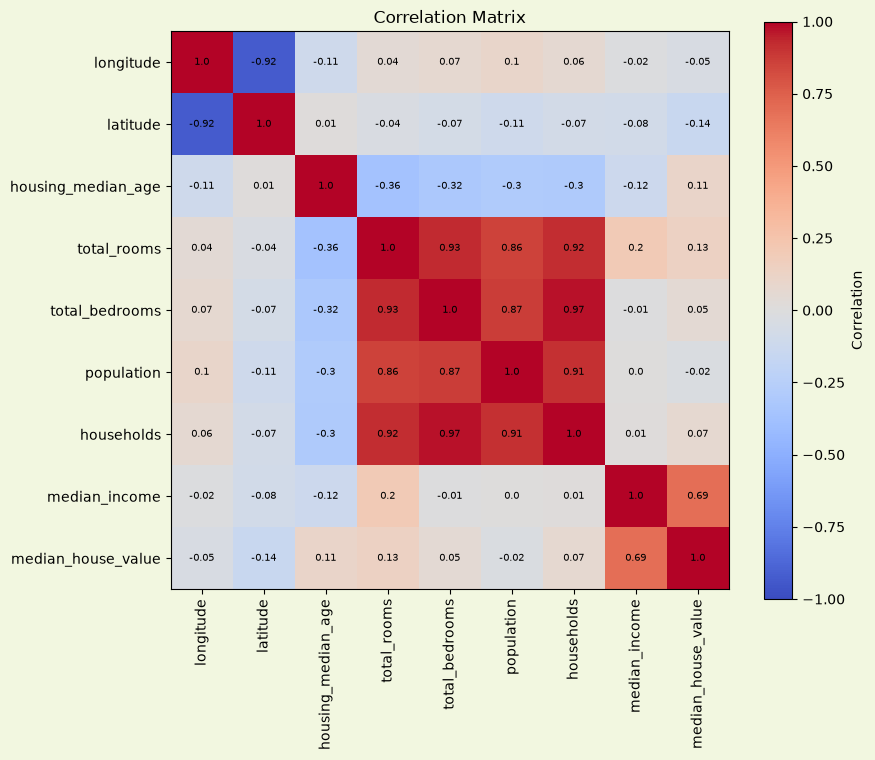

In [254]:
#heatmap
plt.figure(figsize=(9, 7.5))
plt.gcf().set_facecolor("#f2f7e0")
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center", fontsize=7)
plt.title("Correlation Matrix")
plt.show()

median_income at 0.69 is way ahead of everything else, nothing else even hits 0.15. There's also a big red block where total_rooms, total_bedrooms, population and households are all 0.86-0.97 with each other those 4 are basically measuring the same thing (how big the district is) 4 different ways. Longitude and latitude are at -0.92 too, but that's not really a relationship between them, that's just California being a diagonal state.

## Reflection

**Q1 Which features appear most strongly related to median house value?**

median_income by a mile at 0.69. Nothing else is even close, total_rooms is next at 0.13 and everything else is basically noise. But the map plot showed location matters a ton too, even though longitude is only -0.05 and latitude -0.14. That's because correlation only catches straight line relationships, and location works more like "close to the Bay or LA = expensive" which isn't a straight line.

**Q2 Are any input features highly correlated with each other?**

Yeah, a lot. total_rooms, total_bedrooms, population and households are all 0.86 to 0.97 with each other, which makes sense since they're all just measuring how big the district is in different ways. total_bedrooms and households are the worst at 0.97. That's collinearity and it means those 4 are mostly redundant I could probably drop some without losing much. Longitude and latitude are at -0.92 but that's not really a relationship, that's just California being a diagonal state.

**Q3 Do you see any nonlinear relationships that a simple linear model might struggle with?**

Yes, two big ones. First the income scatterplot has that solid line of dots across the top at 500000 from the cap, so price rises with income and then just stops dead. A straight line can't do goes up then flatlines. Second is location. The map shows expensive areas clustered around specific coastal cities, not spread out in one direction. A linear model can only ask "does price go up as longitude goes up" and the answer is no, which is why longitude correlates at basically zero even though the map clearly shows location matters.

**Q4 How well do you expect a linear regression to perform compared to an MLP regressor?**

The MLP should do better. Linear regression would probably do okay just off median_income since that's a decent straight line relationship, but it would miss the location stuff completely and it can't handle the cap flattening things out at the top. An MLP has hidden layers so it can learn "these specific lat/long areas are expensive" and bend around the flat part. Same as banknote in 2.2 where I said the MLP would win because the classes overlapped, except here the reason is the relationships are curved instead of straight.